In [1]:
from os.path import realpath

# Local steps to run in pycharm
# conda activate sage
# jupyter lab --no-browser --port=8888
# configure external server with the token
# sagemath (10.7)

from sage.all import *
from sage.plot.plot import graphics_array
from itertools import combinations
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
})

def graph_square(H):
    G = Graph()
    G.add_vertices(H.vertices())
    for u in H.vertices():
        for v in H.vertices():
            if u < v and H.distance(u,v) <= 2:
                G.add_edge(u,v)
    return G

def is_square_root(G, H):
    return graph_square(H) == G

def find_square_root(G):
    V = list(G.vertices())
    n = len(V)
    pairs = list(combinations(range(n), 2))

    total = 1 << len(pairs)
    for mask in range(total):
        H = Graph()
        H.add_vertices(V)
        for bit, (i, j) in enumerate(pairs):
            if (mask >> bit) & 1:
                H.add_edge(V[i], V[j])
        if is_square_root(G, H):
            return H
    return None

In [2]:
from collections import Counter

# Efficient find_square_root function
def violates_partial(G, H):
    for u, v in combinations(H.vertices(), 2):
        try:
            d = H.distance(u, v)
        except (ValueError, RuntimeError):
            continue

        if H.has_edge(u, v) and not G.has_edge(u, v):
            return True
        if d <= 2 and not G.has_edge(u, v):
            return True
    return False

def find_square_root(G):
    V = list(G.vertices())
    pairs = list(combinations(V, 2))
    H = Graph()
    H.add_vertices(V)

    def backtrack(idx):
        if idx == len(pairs):
            return H.copy() if is_square_root(G, H) else None

        u, v = pairs[idx]

        H.add_edge(u, v)
        if not violates_partial(G, H):
            result = backtrack(idx + 1)
            if result:
                return result
        H.delete_edge(u, v)

        if not violates_partial(G, H):
            result = backtrack(idx + 1)
            if result:
                return result

        return None

    return backtrack(0)


def find_all_square_roots(G):

    V = list(G.vertices())

    edges_G = {
        tuple(sorted(e))
        for e in G.edges(labels=False)
    }

    all_edges = list(combinations(V, 2))

    # Precompute automorphisms once
    aut_maps = [
        phi.dict()
        for phi in G.automorphism_group()
    ]

    total_roots = 0
    roots = []

    orbit_reps = {}

    def backtrack(idx, current_edges):

        nonlocal total_roots

        if idx == len(all_edges):

            H = Graph()
            H.add_vertices(V)
            H.add_edges(current_edges)

            if {
                tuple(sorted(e))
                for e in graph_square(H).edges(labels=False)
            } != edges_G:
                return

            total_roots += 1
            roots.append(H.copy())

            #
            # Fast orbit representative
            #

            edge_set = tuple(
                sorted(
                    tuple(sorted(e))
                    for e in current_edges
                )
            )

            best_key = edge_set

            for phi in aut_maps:

                transformed = tuple(
                    sorted(
                        (
                            min(phi[u], phi[v]),
                            max(phi[u], phi[v])
                        )
                        for (u, v) in edge_set
                    )
                )

                if transformed < best_key:
                    best_key = transformed

            if best_key not in orbit_reps:
                orbit_reps[best_key] = H.copy()

            return

        u, v = all_edges[idx]

        H_partial = Graph()
        H_partial.add_vertices(V)
        H_partial.add_edges(current_edges)
        H_partial.add_edge(u, v)

        valid = True

        for e in graph_square(H_partial).edges(labels=False):
            if tuple(sorted(e)) not in edges_G:
                valid = False
                break

        if valid:
            current_edges.append((u, v))
            backtrack(idx + 1, current_edges)
            current_edges.pop()

        backtrack(idx + 1, current_edges)

    backtrack(0, [])

    edge_counts = Counter()

    for H in roots:
        for e in H.edges(labels=False):
            edge_counts[tuple(sorted(e))] += 1

    if total_roots == 0:
        edge_probabilities = {
            e: None
            for e in all_edges
        }
    else:
        edge_probabilities = {
            e: edge_counts[e] / total_roots
            for e in all_edges
        }

    orbit_list = list(orbit_reps.values())

    return {
        "total_roots": total_roots,
        "roots": roots,
        "non_isomorphic": orbit_list,
        "canonical_roots": [
            H.canonical_label()
            for H in orbit_list
        ],
        "non_isomorphic_count": len(orbit_list),
        "edge_counts": dict(edge_counts),
        "edge_probabilities": edge_probabilities
    }

In [3]:
# LP with max objective function and additional triangle constraints for tetrahedral 4-cliques
# Also includes single triangular decomposition
def max_tetrahedron_linear_program(G):
    m = MixedIntegerLinearProgram(solver = 'GLPK', maximization=False)
    m.solver_parameter("simplex_or_intopt", "intopt_only")

    x = m.new_variable(real=True, nonnegative=True)
    y = m.new_variable(real=True, nonnegative=True)
    z = m.new_variable(real=True, nonnegative=True)

    A_G = G.adjacency_matrix()
    n = A_G.nrows()
    M = n**2

    # Indicator argument
    for i in range(n):
        for j in range(n):
            if i == j:
                m.add_constraint(z[i,j] - (sum(y[i,k,j] for k in range(n)) - sum(x[i,k] for k in range(n)) + x[i,j]) == 0)
            else:
                m.add_constraint(z[i,j] - (sum(y[i,k,j] for k in range(n)) + x[i,j]) == 0)

    # Indicator function
    for i in range(n):
        for j in range(n):
            m.add_constraint(z[i,j] - M * A_G[i][j] <= 0)
            m.add_constraint(-z[i,j] + A_G[i][j] <= 0)

    # Product
    for i in range(n):
        for j in range(n):
            for k in range(n):
                m.add_constraint(y[i,k,j] - x[i,k] <= 0)
                m.add_constraint(y[i,k,j] - x[k,j] <= 0)
                m.add_constraint(- y[i,k,j] + x[i,k] + x[k,j] - 1 <= 0)

    # Symmetry
    for i in range(n):
        for j in range(n):
            m.add_constraint(x[i,j] == x[j,i])

    # Diagonal
    for i in range(n):
        m.add_constraint(x[i,i] == 0)

    # Variables
    for i in range(n):
        for j in range(n):
            m.add_constraint(x[i,j] - 1 <= 0)
            for k in range(n):
                m.add_constraint(y[i,k,j] - 1 <= 0)

    # Count triangles and consider vertices in only one triangle O(n^3)
    deg = {v: G.degree(v) for v in range(n)}
    triangles_at = {v: [] for v in range(n)}

    for i in range(n):
        for j in range(i+1, n):
            if not G.has_edge(i, j):
                continue
            for k in range(j+1, n):
                if G.has_edge(i, k) and G.has_edge(j, k):
                    triangles_at[i].append((j, k))
                    triangles_at[j].append((i, k))
                    triangles_at[k].append((i, j))

    fixed_edges = set()
    fixed_leaf_vertices = set()
    processed_k4s = set()
    fixed_triangle_internal = set()
    fixed_pendant_internal = set()

    # Single triangular decomposition
    for s, tris in triangles_at.items():
        if len(tris) != 1:
            continue

        u, v = tris[0]

        edge_uv = tuple(sorted((u, v)))

        if edge_uv in fixed_edges:
            continue

        if deg[u] <= deg[v]:
            a = u
            b = v
        else:
            a = v
            b = u

        print(f"K3 found | "f"internal={a}, "f"external={b}, "f"leaf=({s})")

        m.add_constraint(x[s, a] == 1)
        m.add_constraint(x[a, s] == 1)

        m.add_constraint(x[a, b] == 1)
        m.add_constraint(x[b, a] == 1)

        fixed_edges.add(edge_uv)
        fixed_pendant_internal.add(a)

    # Tetrahedron Decomposition
    used_k4_internal = set()

    for a in range(n):
        for b in range(a + 1, n):

            if not G.has_edge(a, b):
                continue

            u, v = (a, b) if deg[a] <= deg[b] else (b, a)

            # internal vertex may only occur once
            if u in used_k4_internal:
                continue

            # tetrahedron internal cannot be triangle internal
            if u in fixed_triangle_internal:
                continue

            # tetrahedron internal cannot be pendant internal
            if u in fixed_pendant_internal:
                continue

            common = [
                w for w in G.neighbors(a)
                if w != b and G.has_edge(w, b)
            ]

            best_key = None
            best_pair = None

            for i in range(len(common)):
                for j in range(i + 1, len(common)):

                    s1 = common[i]
                    s2 = common[j]

                    # must close K4
                    if not G.has_edge(s1, s2):
                        continue

                    # leaves already used elsewhere
                    if s1 in fixed_leaf_vertices:
                        continue

                    if s2 in fixed_leaf_vertices:
                        continue

                    k4 = tuple(sorted((u, v, s1, s2)))

                    if k4 in processed_k4s:
                        continue

                    K4_vertices = {u, v, s1, s2}

                    Ns1 = set(G.neighbors(s1)) - K4_vertices
                    Ns2 = set(G.neighbors(s2)) - K4_vertices
                    Nu  = set(G.neighbors(u))  - K4_vertices
                    Nv  = set(G.neighbors(v))  - K4_vertices

                    # leaf neighbourhoods cannot touch existing pendant internals
                    if Ns1 & fixed_pendant_internal:
                        continue

                    if Ns2 & fixed_pendant_internal:
                        continue

                    # leaves must have identical external neighbourhoods
                    if Ns1 != Ns2:
                        continue

                    valid_leaf_class = True
                    for w in Ns1:

                        outside = (
                            set(G.neighbors(w))
                            - K4_vertices
                            - Ns1
                        )

                        if outside:
                            valid_leaf_class = False
                            break

                    if not valid_leaf_class:
                        continue

                    # leaf neighbourhood strictly contained in internal neighbourhood
                    if not (Ns1 < Nu):
                        continue

                    # internal neighbourhood contained in external neighbourhood
                    if not (Nu <= Nv):
                        continue

                    key = (
                        len(Ns1),
                        len(Nu),
                        len(Nv),
                        deg[s1] + deg[s2],
                        min(s1, s2),
                        max(s1, s2),
                    )

                    if best_key is None or key < best_key:
                        best_key = key
                        best_pair = (s1, s2, k4)

            if best_pair is None:
                continue

            s1, s2, k4 = best_pair

            print(
                f"K4 found | "
                f"internal={u}, "
                f"external={v}, "
                f"leaves=({s1}, {s2})"
            )

            m.add_constraint(x[s1, u] == 1)
            m.add_constraint(x[u, s1] == 1)

            m.add_constraint(x[s2, u] == 1)
            m.add_constraint(x[u, s2] == 1)

            m.add_constraint(x[u, v] == 1)
            m.add_constraint(x[v, u] == 1)

            fixed_leaf_vertices.add(s1)
            fixed_leaf_vertices.add(s2)

            used_k4_internal.add(u)

            fixed_edges.add(tuple(sorted((u, v))))
            processed_k4s.add(k4)

    m.set_objective(-m.sum(x[i, j] for i in range(n) for j in range(n)))
    return m, x

In [4]:
# Generate all possible graph squares/roots for given n
import os
import itertools
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sage.numerical.mip import MIPSolverException
from sage.graphs.graph_generators import graphs as graph_gens

n = 6
ncpus = 12
dir = f"isomorphism_max_tetrahedron_decomposition_triangular_graph_output"
output_dir = os.path.join(dir, f"n={n}")
output_pdf = os.path.join(output_dir, f"graph_results_n={n}.pdf")
comparison_pdf = os.path.join(output_dir, f"graph_comparison_n={n}.pdf")
summary_file = os.path.join(output_dir, f"graph_summary_n={n}.txt")
edge_file = os.path.join(output_dir, f"graph_edges_n={n}.txt")

os.makedirs(output_dir, exist_ok=True)
os.makedirs(dir, exist_ok=True)

def error_plot(message):
    g = Graphics()
    g += text(message, (0, 0), fontsize=14, color="red", horizontal_alignment='center')
    g.axes(False)
    return g

def is_claw_free_graph(G):
    for v in G.vertices():
        N = G.neighbors(v)
        if len(N) < 3:
            continue
        for a in range(len(N)):
            for b in range(a+1, len(N)):
                for c in range(b+1, len(N)):
                    u1, u2, u3 = N[a], N[b], N[c]
                    if (not G.has_edge(u1, u2) and
                        not G.has_edge(u1, u3) and
                        not G.has_edge(u2, u3)):
                        return False
    return True

def is_dismantlable_graph(G):
    G_1 = G.copy()

    while G_1.order() > 1:
        found = False

        for v in G_1.vertices():
            Nv = set(G_1.neighbors(v)) | {v}

            for u in G_1.vertices():
                if u == v:
                    continue

                Nu = set(G_1.neighbors(u)) | {u}

                if Nv.issubset(Nu):
                    G_1.delete_vertex(v)
                    found = True
                    break

            if found:
                break

        if not found:
            return False

    return True

def process_graph(idx, G, label):
    G.relabel(range(G.order()))
    n = G.order()

    A_H = None
    sol_H = None
    H = None
    lp_status = "unknown"
    has_root = False
    edges_H = None
    is_noninteger = False

    try:
        m, x = max_tetrahedron_linear_program(G)
        m.solve()
        solution_x = m.get_values(x)
        A_H = matrix([[solution_x[i, j] for j in range(n)] for i in range(n)])
        sol_H = Graph(A_H, weighted=True)
        for (u, v, w) in sol_H.edges():
            sol_H.set_edge_label(u, v, round(w, 3))
        p1 = sol_H.plot(edge_labels=True, title='Weighted LP H')
        lp_status = "feasible"

        if any(abs(A_H[i, j] - round(A_H[i, j])) > 1e-6 for i in range(n) for j in range(n)):
            is_noninteger = True

    except MIPSolverException:
        sol_H = None
        p1 = error_plot("LP infeasible")
        lp_status = "infeasible"

    root_info = find_all_square_roots(G)
    num_total_roots = root_info["total_roots"]
    roots = root_info["roots"]
    unique_roots = root_info["non_isomorphic"]
    num_unique_roots = root_info["non_isomorphic_count"]
    H = unique_roots[0] if unique_roots else None

    root_properties = {
        "is_tree": None,
        "is_bipartite": None,
        "is_proper_interval": None,
        "is_girth_more_than_six": None,
        "is_block": None,
        "is_comparability": None,
        "is_dismantlable": None
    }

    if H is None:
        p2 = error_plot("No feasible H")
        has_root = False
        edges_H = None
    else:
        p2 = H.plot(title='Feasible H')
        has_root = True
        edges_H = H.size()

        root_properties["is_tree"] = H.is_tree()
        root_properties["is_bipartite"] = H.is_bipartite()
        is_interval = H.is_interval()
        is_claw_free = is_claw_free_graph(H)
        root_properties["is_proper_interval"] = is_interval and is_claw_free

        if H.is_tree():
            root_properties["is_girth_more_than_six"] = True
        else:
            g = H.girth()
            root_properties["is_girth_more_than_six"] = (g is not None and g > 6)

        root_properties["is_block"] = H.is_block_graph()
        root_properties["is_comparability"] = H.is_comparability()
        root_properties["is_dismantlable"] = is_dismantlable_graph(H)

    p3 = G.plot(title=f"{label} G (#{idx})")

    summary = {
        "index": idx,
        "edges_G": G.size(),
        "vertices_G": n,
        "lp_status": lp_status,
        "has_root": has_root,
        "edges_H": H.size() if H else None,
        "is_noninteger": is_noninteger,
        "total_roots": num_total_roots,
        "unique_roots": num_unique_roots,
        "edge_probabilities": root_info["edge_probabilities"],
        **root_properties
    }

    is_mismatch = (is_noninteger or (lp_status == "feasible" and H is None))

    if is_mismatch:
        if sol_H is not None:
            p_left = sol_H.plot(edge_labels=True, title="Weighted LP H")
        else:
            p_left = error_plot("No LP solution")

        if H is not None:
            p_mid = H.plot(title="Feasible H")
        else:
            p_mid = error_plot("No discrete H")

        p_right = G.plot(title="Original G")
        comparison = graphics_array([p_left, p_mid, p_right])
    else:
        comparison = None

    return (p1, p2, p3), summary, comparison, is_mismatch

def analyze_isomorphic_lp(G):
    n = G.order()
    perms = itertools.permutations(range(n))

    integer_count = 0
    fractional_count = 0
    infeasible_count = 0

    for perm in perms:
        Gp = G.relabel(dict(zip(range(n), perm)), inplace=False)

        try:
            m, x = max_tetrahedron_linear_program(Gp)
            m.solve()
            sol = m.get_values(x)

            A = matrix([[sol[i, j] for j in range(n)] for i in range(n)])

            is_fractional = any(
                abs(A[i, j] - round(A[i, j])) > 1e-6
                for i in range(n)
                for j in range(n)
            )

            if is_fractional:
                fractional_count += 1
            else:
                integer_count += 1

        except MIPSolverException:
            infeasible_count += 1

    return {
        "total_perms": factorial(n),
        "integer": integer_count,
        "fractional": fractional_count,
        "infeasible": infeasible_count
    }

def run_task(idx, G, label):
    return process_graph(idx, G, label)

tasks = [(i, Graph(G0)) for i, G0 in enumerate(graph_gens.nauty_geng(str(n)))]

results = []
mismatch_results = []

for idx, G in tasks:
    plot_G, summary_G, comp_G, mismatch_G = run_task(idx, G, label="Original")
    if summary_G["is_noninteger"] and summary_G["has_root"]:
        iso_diag = analyze_isomorphic_lp(G)
        summary_G["iso_analysis"] = iso_diag

    if mismatch_G and comp_G is not None:
        mismatch_results.append((comp_G, summary_G))

    (p1, p2, p3) = plot_G

    combined = graphics_array([[p1, p2, p3]])
    results.append((combined, summary_G))

    print(
        f"✅ Graph {summary_G['index']:>4}: "
        f"LP={summary_G['lp_status']} "
        f"Root={summary_G['has_root']} "
        f"{'(⚠️ mismatch)' if mismatch_G else ''}"
    )

with open(summary_file, "w") as f:
    header = (
        f"{'Graph':>5} | {'Verts':>5} | {'Edges(G)':>8} | "
        f"{'Roots':>7} | {'NonIso':>7} | "
        f"{'Edges(H)':>8} | {'LP':>10} | {'Root':>5} | "
        f"{'NonInt':>7} | "
        f"{'Tree':>5} | {'Bip':>5} | {'PropInt':>7} | "
        f"{'Girth>6':>8} | {'Block':>5} | {'Comparability':>5} | "
        f"{'Dismantlable':>5}\n"
    )
    f.write(header)
    f.write("-" * len(header) + "\n")

    for _, s in results:
        f.write(
            f"{s['index']:>5} | "
            f"{s['vertices_G']:>5} | "
            f"{s['edges_G']:>8} | "
            f"{s['total_roots']:>7} | "
            f"{s['unique_roots']:>7} | "
            f"{str(s['edges_H']) if s['edges_H'] is not None else 'NA':>8} | "
            f"{s['lp_status']:<10} | "
            f"{'Yes' if s['has_root'] else 'No':>5} | "
            f"{'Yes' if s['is_noninteger'] else 'No':>7} | "
            f"{'Yes' if s['is_tree'] else 'No':>5} | "
            f"{'Yes' if s['is_bipartite'] else 'No':>5} | "
            f"{'Yes' if s['is_proper_interval'] else 'No':>7} | "
            f"{'Yes' if s['is_girth_more_than_six'] else 'No':>8} | "
            f"{'Yes' if s['is_block'] else 'No':>5} | "
            f"{'Yes' if s['is_comparability'] else 'No':>5} |"
            f"{'Yes' if s['is_dismantlable'] else 'No':>5}\n"
        )

        if "iso_analysis" in s:

            iso = s["iso_analysis"]

            f.write(
                f"      ISO CHECK → perms={iso['total_perms']} | "
                f"integer={iso['integer']} | "
                f"fractional={iso['fractional']} | "
                f"infeasible={iso['infeasible']}\n"
            )

        f.write("-" * len(header) + "\n")

print(f"📝 Summary written to {summary_file}")

with PdfPages(output_pdf) as pdf:
    for p, sG in results:
        fig = p.matplotlib(figsize=(12, 4))
        pdf.savefig(fig)
        plt.close(fig)
print(f"\n✅ Combined {len(results)} graphs into {output_pdf}")


if mismatch_results:
    with PdfPages(comparison_pdf) as pdf:
        for comp, s in mismatch_results:

            fig = comp.matplotlib(figsize=(12, 4))

            plt.suptitle(
                f"Graph {s['index']} — "
                f"LP={s['lp_status']} | "
                f"Root={s['has_root']} | "
                f"{'Non-integer LP' if s['is_noninteger'] else ''}"
            )

            pdf.savefig(fig)
            plt.close(fig)

    print(f"⚠️ Comparison mismatches saved to {comparison_pdf}")

with open(edge_file, "w") as f:
    pairs = list(combinations(range(n), 2))
    header = (
        ["graph_id"]
        + [str(e) for e in pairs]
    )
    f.write("|".join(header) + "\n")
    for _, s in results:
        probs = s["edge_probabilities"]
        row = [str(s["index"])]
        row.extend(
            f"{probs[e]:.6f}"
            if probs[e] is not None
            else "NA"
            for e in pairs
        )
        f.write("|".join(row) + "\n")
    print(f"✅ Edges saved to {edge_file}")

✅ Graph    0: LP=feasible Root=True 
✅ Graph    1: LP=feasible Root=True 
✅ Graph    2: LP=infeasible Root=False 
✅ Graph    3: LP=infeasible Root=False 
✅ Graph    4: LP=infeasible Root=False 
✅ Graph    5: LP=infeasible Root=False 
✅ Graph    6: LP=feasible Root=True 
✅ Graph    7: LP=infeasible Root=False 
✅ Graph    8: LP=infeasible Root=False 
K3 found | internal=4, external=5, leaf=(0)
K3 found | internal=0, external=5, leaf=(4)
K3 found | internal=0, external=4, leaf=(5)
✅ Graph    9: LP=feasible Root=True 
✅ Graph   10: LP=infeasible Root=False 
✅ Graph   11: LP=infeasible Root=False 
K3 found | internal=4, external=5, leaf=(0)
K3 found | internal=0, external=5, leaf=(4)
K3 found | internal=0, external=4, leaf=(5)
✅ Graph   12: LP=infeasible Root=False 
✅ Graph   13: LP=infeasible Root=False 
K3 found | internal=4, external=5, leaf=(0)
K3 found | internal=0, external=5, leaf=(4)
K3 found | internal=0, external=4, leaf=(5)
✅ Graph   14: LP=infeasible Root=False 
K3 found | inter

<Figure size 640x480 with 0 Axes>

In [5]:
n = 6
edge_filename = f"isomorphism_max_tetrahedron_decomposition_triangular_graph_output/n={n}/graph_edges_n={n}.txt"
filename = f"isomorphism_max_tetrahedron_decomposition_triangular_graph_output/n={n}/graph_summary_n={n}.txt"

summary = {}
graph_info = {}
iso_effects = []
original_status = {}
current_graph = None
total_graphs = 0

edge_info = {}

with open(edge_filename, "r") as f:

    header = [x.strip() for x in f.readline().split("|")]

    edge_names = header[1:]

    for line in f:

        parts = [x.strip() for x in line.split("|")]

        graph_id = int(parts[0])

        probs = {}

        for edge, value in zip(edge_names, parts[1:]):

            probs[edge] = (
                None if value == "NA"
                else float(value)
            )

        edge_info[graph_id] = probs

with open(filename, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if not line or line.startswith("-") or line.startswith("SUMMARY") or line.startswith("Graph"):
            continue

        if line.startswith("ISO CHECK"):
            if current_graph is None:
                continue

            parts = [p.strip() for p in line.replace("ISO CHECK →", "").split("|")]

            iso_data = {}
            for p in parts:
                key, value = p.split("=")
                iso_data[key.strip()] = int(value.strip())

            graph_info[current_graph]["ISO"] = iso_data
            continue

        parts = [p.strip() for p in line.split("|")]

        if len(parts) != 16:
            continue

        (
            graph,
            verts,
            edges_g,
            roots_total,
            roots_unique,
            edges_h,
            lp,
            root,
            nonint,
            tree,
            bip,
            propint,
            girth6,
            block,
            comparability,
            dismantlable
        ) = parts

        idx = int(graph)
        current_graph = idx

        total_graphs += 1

        roots_total = int(roots_total)
        roots_unique = int(roots_unique)

        H_exists = (root == "Yes")

        if lp == "infeasible":
            LP_type = "LP infeasible"
        elif nonint == "Yes":
            LP_type = "LP fractional"
        else:
            LP_type = "LP integer"

        key = (H_exists, LP_type)
        summary.setdefault(key, []).append(idx)

        graph_info[idx] = {
            "H_exists": H_exists,
            "LP_type": LP_type,
            "TotalRoots": roots_total,
            "NonIsoRoots": roots_unique,
            "Tree": tree,
            "Bip": bip,
            "PropInt": propint,
            "Girth>6": girth6,
            "Block": block,
            "Comparability": comparability,
            "Dismantlable": dismantlable,
            "EdgeProbs": edge_info.get(idx, {})
        }

for (H_exists, LP_type), graphs in sorted(summary.items()):
    print(
        f"H exists: {str(H_exists):<5} | "
        f"{LP_type:<15} → "
        f"{len(graphs)} graphs"
    )

properties = [
    ("Tree", "Tree"),
    ("Bip", "Bipartite"),
    ("PropInt", "Proper Interval"),
    ("Girth>6", "Girth > 6"),
    ("Block", "Block Graph"),
    ("Comparability", "Comparability"),
    ("Dismantlable", "Dismantlable")
]

for key, label in properties:

    H_true_yes = 0
    H_true_no = 0
    H_false_yes = 0
    H_false_no = 0

    for info in graph_info.values():

        if info["LP_type"] != "LP fractional":
            continue

        H = info["H_exists"]
        val = info[key]

        if H:
            if val == "Yes":
                H_true_yes += 1
            else:
                H_true_no += 1
        else:
            if val == "Yes":
                H_false_yes += 1
            else:
                H_false_no += 1

    print(f"\n{label} for fractional solutions")
    print(f"H=True  | {label}=Yes → {H_true_yes}")
    print(f"H=True  | {label}=No  → {H_true_no}")
    print(f"H=False | {label}=Yes → {H_false_yes}")
    print(f"H=False | {label}=No  → {H_false_no}")

print()

for idx in sorted(graph_info):

    info = graph_info[idx]

    if not (not info["LP_type"] == "LP integer" and info["H_exists"]):
        continue

    warning = (
        info["Tree"] == "No"
        and info["Bip"] == "No"
        and info["PropInt"] == "No"
        and info["Girth>6"] == "No"
        and info["Block"] == "No"
    )

    warn_symbol = " ⚠" if warning else ""

    print(f"Graph {idx}{warn_symbol}")

    print(
        f"  Original → "
        f"H exists: {info['H_exists']} | "
        f"{info['LP_type']}"
    )

    print(
        f"  Roots: {info['TotalRoots']} iso | "
        f"{info['NonIsoRoots']} non-iso"
    )

    print(
        f"  Properties: "
        f"Tree={info['Tree']} "
        f"Bip={info['Bip']} "
        f"PI={info['PropInt']} "
        f"Girth>6={info['Girth>6']} "
        f"Block={info['Block']} "
        f"Comparability={info['Comparability']} "
        f"Dismantlable={info['Dismantlable']}"
    )

    if "ISO" in info:
        iso = info["ISO"]
        print("  ISO permutations:", iso["perms"])
        print("     Integer:", iso["integer"])
        print("     Fractional:", iso["fractional"])
        print("     Infeasible:", iso["infeasible"])

    edge_probs = info["EdgeProbs"]

    if edge_probs:

        print("  Root-edge frequencies:")

        forced = []
        forbidden = []
        fractional = []

        for edge, p in edge_probs.items():

            if p is None:
                continue

            if abs(p - 1.0) < 1e-9:
                forced.append(edge)

            elif abs(p) < 1e-9:
                forbidden.append(edge)

            else:
                fractional.append((edge, p))

        if forced:
            print("     Forced:")
            print("       ", ", ".join(forced))

        if forbidden:
            print("     Forbidden:")
            print("       ", ", ".join(forbidden))

        if fractional:
            print("     Variable:")

            for edge, p in sorted(fractional, key=lambda x: -x[1]):
                print(f"       {edge}: {p:.3f}")

    print()


H exists: False | LP fractional   → 7 graphs
H exists: False | LP infeasible   → 121 graphs
H exists: True  | LP fractional   → 3 graphs
H exists: True  | LP integer      → 25 graphs

Tree for fractional solutions
H=True  | Tree=Yes → 0
H=True  | Tree=No  → 3
H=False | Tree=Yes → 0
H=False | Tree=No  → 7

Bipartite for fractional solutions
H=True  | Bipartite=Yes → 1
H=True  | Bipartite=No  → 2
H=False | Bipartite=Yes → 0
H=False | Bipartite=No  → 7

Proper Interval for fractional solutions
H=True  | Proper Interval=Yes → 1
H=True  | Proper Interval=No  → 2
H=False | Proper Interval=Yes → 0
H=False | Proper Interval=No  → 7

Girth > 6 for fractional solutions
H=True  | Girth > 6=Yes → 0
H=True  | Girth > 6=No  → 3
H=False | Girth > 6=Yes → 0
H=False | Girth > 6=No  → 7

Block Graph for fractional solutions
H=True  | Block Graph=Yes → 1
H=True  | Block Graph=No  → 2
H=False | Block Graph=Yes → 0
H=False | Block Graph=No  → 7

Comparability for fractional solutions
H=True  | Comparabilit

Graph 3
Vertices: 3
Edges: 3
K3 found | internal=1, external=2, leaf=(0)
K3 found | internal=0, external=2, leaf=(1)
K3 found | internal=0, external=1, leaf=(2)

LP status : feasible
LP type   : integer

Square roots
Total labeled     : 4
Non-isomorphic    : 2

Triangles per vertex in G
  v0: 1
  v1: 1
  v2: 1

Root-edge frequencies

  Variable:
    (0, 1): 0.750
    (0, 2): 0.750
    (1, 2): 0.750

LP weights versus root frequencies
  (0,1) : LP=1.000   RootFreq=0.750
  (0,2) : LP=1.000   RootFreq=0.750
  (1,2) : LP=1.000   RootFreq=0.750

Vertex    LPdeg  RootDeg       L1       L2    LP+   IntLP
------------------------------------------------------------
     0    2.000    1.500    0.500    0.354      2       2
     1    2.000    1.500    0.500    0.354      2       2
     2    2.000    1.500    0.500    0.354      2       2

Root edges                     : 2.25
LP total edge weight           : 3.000

Original graph G


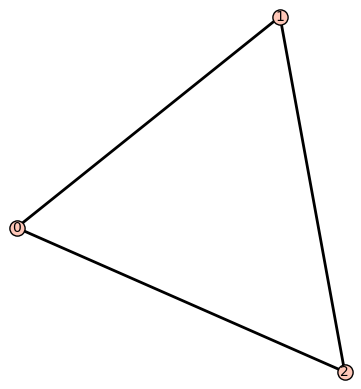


LP solution


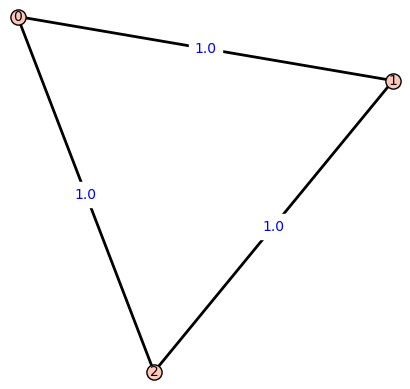


Root 1
  Tree           : False
  Bipartite      : False
  Proper interval: True
  Girth > 6      : False
  Block graph    : True
  Comparability  : True
  Dismantlable   : True


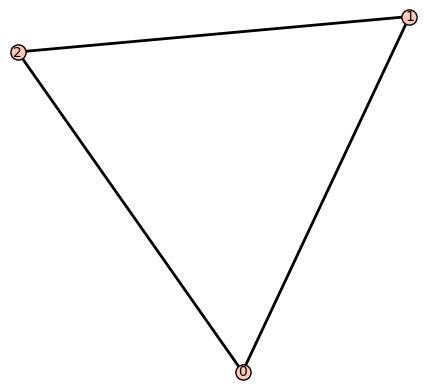


Root 2
  Tree           : True
  Bipartite      : True
  Proper interval: True
  Girth > 6      : True
  Block graph    : True
  Comparability  : True
  Dismantlable   : True


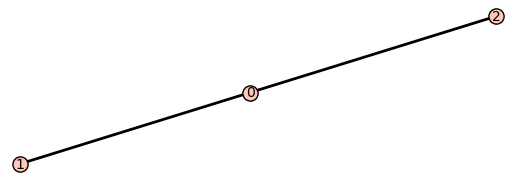

In [6]:
%matplotlib inline

from itertools import combinations

def triangles_per_vertex(G):

    counts = {v: 0 for v in G.vertices()}

    for i, j, k in combinations(G.vertices(), 3):
        if (
            G.has_edge(i, j)
            and G.has_edge(i, k)
            and G.has_edge(j, k)
        ):
            counts[i] += 1
            counts[j] += 1
            counts[k] += 1

    return counts


def analyze_graph_by_index(idx, n):

    G = None

    for i, g in enumerate(graph_gens.nauty_geng(str(n))):
        if i == idx:
            G = Graph(g)
            break

    if G is None:
        print("Graph index not found")
        return

    G.relabel(range(G.order()))

    print("=" * 40)
    print(f"Graph {idx}")
    print("=" * 40)

    print("Vertices:", G.order())
    print("Edges:", G.size())

    H_lp = None
    lp_matrix = None
    lp_type = "unknown"

    try:

        m, x = max_tetrahedron_linear_program(G)

        m.solve()

        sol = m.get_values(x)

        lp_matrix = matrix([
            [sol[i, j] for j in range(G.order())]
            for i in range(G.order())
        ])

        fractional = any(
            abs(lp_matrix[i, j] - round(lp_matrix[i, j])) > 1e-6
            for i in range(G.order())
            for j in range(G.order())
        )

        lp_type = "fractional" if fractional else "integer"

        H_lp = Graph(lp_matrix, weighted=True)

        for (u, v, w) in H_lp.edges():
            H_lp.set_edge_label(u, v, round(w, 3))

        print("\nLP status : feasible")
        print("LP type   :", lp_type)

    except MIPSolverException:

        print("\nLP status : infeasible")
        lp_type = "infeasible"

    root_info = find_all_square_roots(G)

    total_roots = root_info["total_roots"]
    roots = root_info["non_isomorphic"]
    edge_probs = root_info["edge_probabilities"]

    print("\nSquare roots")
    print("Total labeled     :", total_roots)
    print("Non-isomorphic    :", len(roots))

    print("\nTriangles per vertex in G")

    tri = triangles_per_vertex(G)

    for v in sorted(tri):
        print(f"  v{v}: {tri[v]}")

    print("\nRoot-edge frequencies")

    forced = []
    forbidden = []
    variable = []

    for e in sorted(edge_probs):

        p = edge_probs[e]

        if p is None:
            continue

        if abs(p - 1.0) < 1e-9:
            forced.append(e)

        elif abs(p) < 1e-9:
            forbidden.append(e)

        else:
            variable.append((e, p))

    if forced:
        print("\n  Forced:")
        print("   ", ", ".join(map(str, forced)))

    if forbidden:
        print("\n  Forbidden:")
        print("   ", ", ".join(map(str, forbidden)))

    if variable:
        print("\n  Variable:")

        for e, p in sorted(variable, key=lambda x: -x[1]):
            print(f"    {e}: {p:.3f}")

    if lp_matrix is not None:

        print("\nLP weights versus root frequencies")

        for u, v in combinations(range(G.order()), 2):

            lp_val = lp_matrix[u, v]
            root_val = edge_probs[(u, v)]

            if root_val is None:
                continue

            print(
                f"  ({u},{v}) : "
                f"LP={lp_val:.3f}   "
                f"RootFreq={root_val:.3f}"
            )

        lp_degree = {i: 0.0 for i in range(G.order())}
        root_degree = {i: 0 for i in range(G.order())}

        l1_vertex = {i: 0.0 for i in range(G.order())}
        sq_vertex = {i: 0.0 for i in range(G.order())}

        positive_lp = {i: 0 for i in range(G.order())}
        integral_lp = {i: 0 for i in range(G.order())}

        total_lp = 0.0
        total_root = 0
        total_l1 = 0.0

        max_gap = (-1, None)

        for u, v in combinations(range(G.order()), 2):

            lp = float(lp_matrix[u, v])
            root = edge_probs[(u, v)]

            if root is None:
                continue

            lp_degree[u] += lp
            lp_degree[v] += lp

            root_degree[u] += root
            root_degree[v] += root
            total_root += root

            if lp > 1e-8:
                positive_lp[u] += 1
                positive_lp[v] += 1

            if abs(lp - round(lp)) < 1e-8:
                integral_lp[u] += 1
                integral_lp[v] += 1

            d = abs(lp - root)

            l1_vertex[u] += d
            l1_vertex[v] += d

            sq_vertex[u] += d * d
            sq_vertex[v] += d * d

            total_lp += lp
            total_l1 += d

            if d > max_gap[0]:
                max_gap = (d, (u, v))

        print()
        print(
            f"{'Vertex':>6}"
            f"{'LPdeg':>9}"
            f"{'RootDeg':>9}"
            f"{'L1':>9}"
            f"{'L2':>9}"
            f"{'LP+':>7}"
            f"{'IntLP':>8}"
        )

        print("-" * 60)

        for i in range(G.order()):

            print(
                f"{i:>6}"
                f"{lp_degree[i]:>9.3f}"
                f"{root_degree[i]:>9.3f}"
                f"{l1_vertex[i]:>9.3f}"
                f"{sqrt(sq_vertex[i]):>9.3f}"
                f"{positive_lp[i]:>7d}"
                f"{integral_lp[i]:>8d}"
            )

        print()
        print(f"Root edges                     : {total_root}")
        print(f"LP total edge weight           : {total_lp:.3f}")

    print("\nOriginal graph G")

    display(
        G.plot(
            vertex_size=120,
            edge_thickness=2,
            vertex_labels=True,
            figsize=[8, 8],
            title=f"G (#{idx})"
        ).matplotlib()
    )

    if H_lp is not None:

        print("\nLP solution")

        display(
            H_lp.plot(
                vertex_size=120,
                edge_thickness=2,
                edge_labels=True,
                vertex_labels=True,
                figsize=[8, 8],
                title=f"H_lp ({lp_type})"
            ).matplotlib()
        )

    for k, H in enumerate(roots):

        print(f"\nRoot {k+1}")

        print("  Tree           :", H.is_tree())
        print("  Bipartite      :", H.is_bipartite())

        interval = H.is_interval()
        clawfree = is_claw_free_graph(H)

        print("  Proper interval:", interval and clawfree)

        if H.is_tree():
            girth6 = True
        else:
            g = H.girth()
            girth6 = (g is not None and g > 6)

        print("  Girth > 6      :", girth6)
        print("  Block graph    :", H.is_block_graph())
        print("  Comparability  :", H.is_comparability())
        print("  Dismantlable   :", is_dismantlable_graph(H))

        display(
            H.plot(
                vertex_size=120,
                edge_thickness=2,
                vertex_labels=True,
                figsize=[8, 8],
                title=f"Root {k+1}"
            ).matplotlib()
        )

analyze_graph_by_index(3, 3)